# Topic 1: Pricing optimization [20 minutes]
We have implemented different prices for a specific product in one of our markets and gathered the relevant performance data.
Based on this, we now want to find the optimum price to improve our performance. Please analyze the question1_dataset.csv dataset and provide your recommendation in 1 slide along
with the associated analysis methodology.


In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
%pip install -U statsmodels

Note: you may need to restart the kernel to use updated packages.


In [5]:
import statsmodels.api as sm

In [6]:
import statsmodels as sm_pkg  

In [7]:
import statsmodels.formula.api as smf


In [49]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [ ]:
# Load dataset and inspect dataset

In [8]:
df = pd.read_csv("question1_dataset.csv")

In [9]:
df.head()

,day,product_price,product_cost,product_volume,product_page_visitors
0,1,44.99,25,130,7806
1,2,32.49,25,64,2165
2,3,43.99,25,76,4599
3,4,48.99,25,81,6559
4,5,35.99,25,104,4290


In [10]:
df.describe()

,day,product_price,product_cost,product_volume,product_page_visitors
count,360.000000,360.000000,360.0,360.000000,360.000000
mean,180.500000,40.656667,25.0,123.988889,6038.622222
std,104.067286,6.532541,0.0,67.180503,2352.416936
min,1.000000,29.990000,25.0,20.000000,2025.000000
25%,90.750000,34.990000,25.0,69.000000,4101.000000
50%,180.500000,40.490000,25.0,111.500000,5926.000000
75%,270.250000,46.490000,25.0,161.250000,8177.000000
max,360.000000,51.490000,25.0,325.000000,9965.000000


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 360 entries, 0 to 359
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   day                    360 non-null    int64  
 1   product_price          360 non-null    float64
 2   product_cost           360 non-null    int64  
 3   product_volume         360 non-null    int64  
 4   product_page_visitors  360 non-null    int64  
dtypes: float64(1), int64(4)
memory usage: 14.2 KB


In [13]:
# Create correlation matrix

In [14]:
df.corr()

,day,product_price,product_cost,product_volume,product_page_visitors
day,1.000000,-0.080666,NaN,0.104889,0.101049
product_price,-0.080666,1.000000,NaN,-0.637201,-0.061156
product_cost,NaN,NaN,NaN,NaN,NaN
product_volume,0.104889,-0.637201,NaN,1.000000,0.763173
product_page_visitors,0.101049,-0.061156,NaN,0.763173,1.000000


In [16]:
# Because of non linear/ curvilinear nature of relationship, we neeed to take log of variables 

In [17]:
df['volume_ln'] = np.log(df['product_volume'])
df['price_ln'] = np.log(df['product_price'])
df['visitors_ln'] = np.log(df['product_page_visitors'])

In [18]:
# Define the variables in regression model
# Dependent variable = product_volume
# Independent variables = product_price, product_page_visitors

In [19]:
x = sm.add_constant(df[['price_ln', 'visitors_ln']])
y = df['volume_ln']

In [20]:
# Run Ordinary Least Squares(OLS) regrsssion model

In [21]:
reg_model = sm.OLS(y, x).fit()

In [22]:
# Below is the output of regrtession model

In [23]:
print(reg_model.summary())

                            OLS Regression Results                            
Dep. Variable:              volume_ln   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.954
Method:                 Least Squares   F-statistic:                     3746.
Date:                Thu, 16 Oct 2025   Prob (F-statistic):          2.67e-240
Time:                        16:17:28   Log-Likelihood:                 235.17
No. Observations:                 360   AIC:                            -464.3
Df Residuals:                     357   BIC:                            -452.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           3.8158      0.205     18.618      

In [24]:
# Calculate model parameters below

In [25]:
# calculate the price elasticity: It is the coefficient on price_ln
# Elastic: > 1 ( very responsive)
# Unit elastic: = 1
# Inelastic: < 1 quantity is not very responsive.
# Below the calculated Price Elasticity of Demand is - 2.12 

In [26]:
p_elasticity = reg_model.params['price_ln']

In [27]:
print(f"Price Elasticity of Demand: {p_elasticity:.2f}")

Price Elasticity of Demand: -2.12


In [28]:
# calculate R-squared: 

In [29]:
r2 = reg_model.rsquared
print(f"R-squared: {r2:.3f}")

R-squared: 0.955


In [30]:
# Calculate the optimal price
# Formula: p* = cost / (1 + 1/p_elasticity), where cost is marginal cost ($25)
# Note: e must be negative for this to make sense (markup factor)

In [45]:
cost = 25
p = cost / (1 + 1/p_elasticity)
print(f"Optimal Price: EUR {p:.2f}")

Optimal Price: EUR 47.34


In [32]:
# Create a histogram of dependent variable

<Axes: >

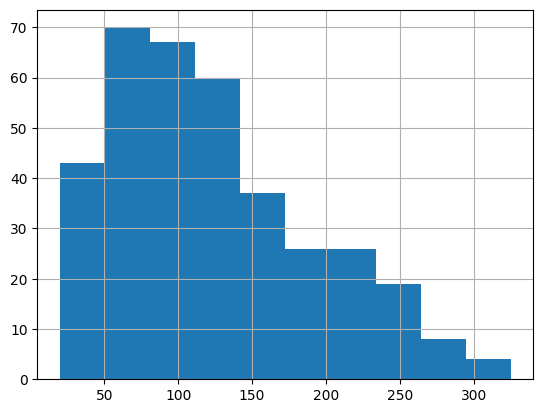

In [46]:
df['product_volume'].hist()

In [34]:
# Plot residuals for model validation

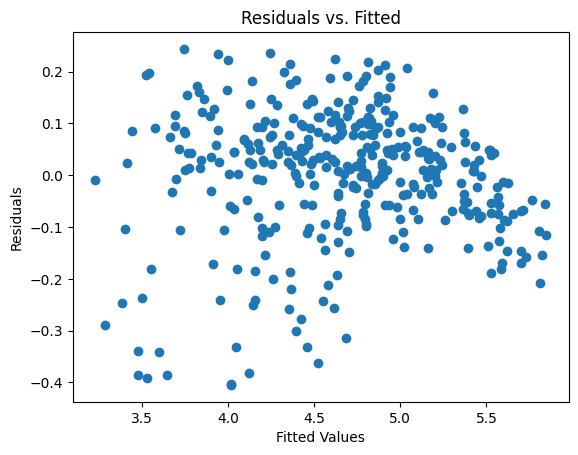

In [47]:
residuals = reg_model.resid
fig, ax = plt.subplots()
ax.scatter(reg_model.fittedvalues, residuals)
ax.set_xlabel('Fitted Values')
ax.set_ylabel('Residuals')
ax.set_title('Residuals vs. Fitted')
plt.show()

In [36]:
# Scatterplot of actual vs predicted volume 

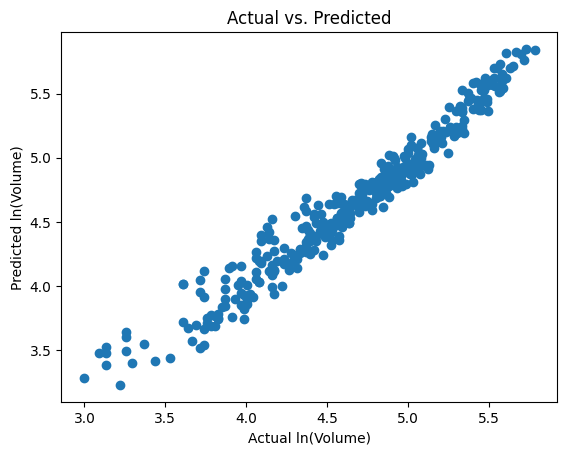

In [37]:
plt.scatter(y, reg_model.fittedvalues)
plt.xlabel('Actual ln(Volume)')
plt.ylabel('Predicted ln(Volume)')
plt.title('Actual vs. Predicted')
plt.show()

In [39]:
# Check for multicollinearity
# Calculate VIF for each independent variable

In [40]:
print(df[['price_ln', 'visitors_ln']].corr())

             price_ln  visitors_ln
price_ln     1.000000    -0.053652
visitors_ln -0.053652     1.000000


In [54]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Add a constant term for the intercept
X_vif = df[['price_ln', 'visitors_ln']].assign(const=1)

vif_df = pd.DataFrame({
    'Variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})

# Display as a clean table
print("\nVariance Inflation Factors (VIF):")
print(vif_df.to_string(index=False))


Variance Inflation Factors (VIF):
   Variable        VIF
   price_ln   1.002887
visitors_ln   1.002887
      const 945.885527


In [42]:

# Random scatter with no pattern indicates homoskedasticity; funnel shape suggests heteroskedasticity.


Breusch-Pagan Test for Homoskedasticity:
Lagrange Multiplier Statistic: 62.0701
p-value: 0.0000
f-value: 37.1883
f p-value: 0.0000
Note: p-value > 0.05 suggests homoskedasticity (constant variance).


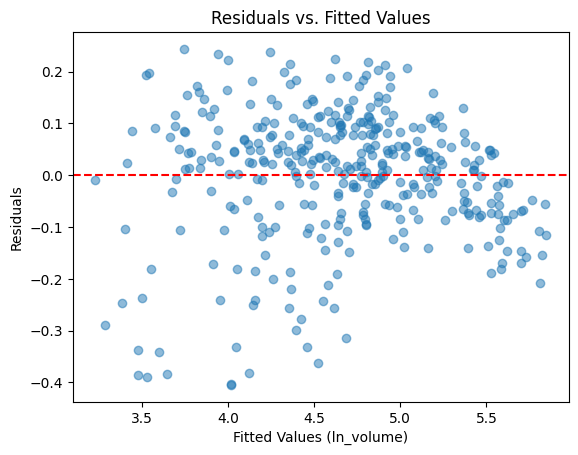

In [43]:
# Import libraries for homoskedasticity check
from statsmodels.stats.diagnostic import het_breuschpagan
import matplotlib.pyplot as plt

# Perform the Breusch-Pagan test on residuals and exog variables
bp_test = het_breuschpagan(reg_model.resid, reg_model.model.exog)

# Define labels for the test results
labels = ['Lagrange Multiplier Statistic', 'p-value', 'f-value', 'f p-value']

# Create a dictionary mapping labels to test results
bp_results = dict(zip(labels, bp_test))

# Print the header for Breusch-Pagan results
print("\nBreusch-Pagan Test for Homoskedasticity:")

# Loop through and print each result with formatting
for label, value in bp_results.items():
    print(f"{label}: {value:.4f}")

# Interpretation note for the test
print("Note: p-value > 0.05 suggests homoskedasticity (constant variance).")

# Create a scatter plot for residuals vs. fitted values
plt.scatter(reg_model.fittedvalues, reg_model.resid, alpha=0.5)

# Add a horizontal line at y=0 for reference
plt.axhline(y=0, color='r', linestyle='--')

# Set x-axis label
plt.xlabel('Fitted Values (ln_volume)')

# Set y-axis label
plt.ylabel('Residuals')

# Set plot title
plt.title('Residuals vs. Fitted Values')

# Display the plot
plt.show()